In [39]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

pio_fields=["participants","interventions","outcomes"]
data=Path("./ebm_nlp_2_00")

#getting test docs
def get_docs(split="test",label_type="participants"):
    if split=="test":
        split="test/gold"
    folder=(data
            /"annotations"
            /"aggregated"
            /"starting_spans"
            /label_type
            /split)
    
    docs_id=[]
    for p in folder.glob("*.AGGREGATED.ann"):
        name=p.stem.split(".")[0]
        docs_id.append(name)
    return sorted(docs_id)

test_p=get_docs("test","participants")
test_i=get_docs("test","interventions")
test_o=get_docs("test","outcomes")
test_doc=sorted(set(test_p)&set(test_i)&set(test_o))

#checking how many documents are actually being used for testing
print("Participants Test Doc No.:",len(test_p))
print("Outcomes Test Doc No.:",len(test_o))
print("Intervention Test Doc No.:",len(test_i))
print("Common test doc for testing:",len(test_doc))

#building gold csv
def get_spans(tokens,labels):
    spans=[]
    current=[]
    for t,l in zip(tokens,labels):
        l=int(l)
        if l!=0:
            current.append(t)
        else:
            if current:
                spans.append(" ".join(current))
                current=[]
    if current:
        spans.append(" ".join(current))
    return spans

def read_token(doc_id):
    path=data/"documents"/f"{doc_id}.tokens"
    with open(path,"r",encoding="utf-8")as f:
        return[line.strip() for line in f]
def read_lbl(doc_id,field,split="test"):
    if split=="test":
        split="test/gold"
    path=(data
          /"annotations"
          /"aggregated"
          /"starting_spans"
          /field
          /split
          /f"{doc_id}.AGGREGATED.ann")
    with open(path,"r",encoding="utf-8") as f:
        return [line.strip() for line in f]
    
def one_doc(doc_id):
    token=read_token(doc_id)
    row={"doc_id":str(doc_id)}
    for field in pio_fields:
        label=read_lbl(doc_id,field)
        span=get_spans(token,label)
        seen=set()
        clean_span=[]
        for s in span:
            if s not in seen:
                seen.add(s)
                clean_span.append(s)
        row[f"{field}_gold"]=";".join(clean_span)
    return row

def gold_doc(doc_ids):
    rows=[]
    for d in doc_ids:
        try:
            rows.append(one_doc(d))
        except Exception as e:
            print(f"skipping{d}:{e}")
    return pd.DataFrame(rows)

gold_df=gold_doc(test_doc)
gold_df.to_csv("gold.csv",index=False)

#cleaning text before test
def clean_span(txt):
    if pd.isna(txt):
        return ""
    txt=str(txt).lower().strip()
    txt = txt.replace("[", "").replace("]", "")
    txt = re.sub(r"[^\w\s]", " ", txt)
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt

def split_span(txt):
    if pd.isna(txt):
        return[]
    txt=str(txt).lower().strip()
    txt=txt.replace("[","").replace("]","")
    if txt=="":
        return []
    span_r=txt.split(";")
    span=[]
    done=set()
    for s in span_r:
        s2=clean_span(s)
        if s2!= "" and s2 not in done:
            span.append(s2)
            done.add(s2)
    return span

#joining gold and pred files
def join_gp(g_csv_path,p_csv_path,variant_label):
    gold_tbl=pd.read_csv(g_csv_path,dtype={"doc_id":str})
    pred_tbl=pd.read_csv(p_csv_path,dtype={"doc_id":str})
    merged=gold_tbl.merge(pred_tbl,on="doc_id",how="left")
    for cl in ["participants_pred","interventions_pred","outcomes_pred"]:
        if cl not in merged.columns:
            merged[cl]=""
        merged[cl]=merged[cl].fillna("")
    merged["variant"]=variant_label
    return merged

#getting outputs from models
tbl_rule=join_gp(
    "gold.csv","./results_axis1A_rule_based.csv",
    "rule_based")
tbl_decomposed=join_gp(
    "gold.csv","./Axis2B_FULL_SUBMISSION.csv",
    "rf_crf")
tbl_biobert=join_gp(
    "gold.csv","./axis1B_BioBERT_pred.csv",
    "biobert")
tbl_pubmedbert=join_gp(
    "gold.csv","./axis1B_PubMedBERT_pred.csv",
    "pubmedbert")
tbl_clinicalbert=join_gp(
    "gold.csv","./axis1B_BioClinical_ModernBERT_pred.csv",
    "clinicalbert")
tbl_fewshot_qwen=join_gp(
    "gold.csv","./axis2A_Few_Shot_qwen_pred.csv",
    "fewshot_qwen")
tbl_zeroshot_qwen=join_gp(
    "gold.csv","./axis2A_Zero_Shot_qwen_pred.csv",
    "zeroshot_qwen")


run_all=pd.concat([
    tbl_rule,tbl_biobert,tbl_pubmedbert,tbl_clinicalbert,
    tbl_decomposed,tbl_fewshot_qwen, tbl_zeroshot_qwen,
    tbl_axis2bresults], ignore_index=True)
print(run_all["variant"].value_counts())

# checki g for exact match in the fields
def exact_m(gold_txt,pred_txt):
    g=clean_span(gold_txt)
    p=clean_span(pred_txt)
    return int(g !="" and g==p)

#calculating f1 when tokens overlap and calculating 
def overlap_f1(gold_txt,pred_txt):
    g=clean_span(gold_txt)
    p=clean_span(pred_txt)
    if g=="" and p=="":
        return 1
    if g=="" or p=="":
        return 0
    
    gold_tkn=g.split()
    pred_tkn=p.split()
    g_count=defaultdict(int)
    p_count=defaultdict(int)
    for w in gold_tkn:
        g_count[w]+=1
    for w in pred_tkn:
        p_count[w]+=1
    shared=0
    for w in g_count:
        shared+=min(g_count[w],p_count[w])
    if shared==0:
        return 0
    prec=shared/len(pred_tkn)
    rec=shared/len(gold_tkn)
    return 2*prec*rec/(prec+rec)

#matching gold span with pred
def match_span(gold_span,pred_span,match_threshold=0.5):
    used_g=set()
    used_p=set()
    tp=0
    for i,g in enumerate(gold_span):
        good_score=0
        best_j=-1
        for j,p in enumerate(pred_span):
            if j in used_p:
                continue
            score=overlap_f1(g,p)
            if score>good_score:
                good_score=score
                best_j=j

        if good_score >= match_threshold and best_j != -1:
            tp += 1
            used_g.add(i)
            used_p.add(best_j)
    fp=len(pred_span)-tp
    fn=len(gold_span)-tp
    return tp,fp,fn
    
#evaluating one field
def e1f(tbl,gold_cl,pred_cl, match_threshold=0.5):
        noempty_g=0
        noempty_p=0
        c=0
        exact_score=[]
        field_f1_score=[]
        tp_all=0
        fp_all=0
        fn_all=0

        for _,row in tbl.iterrows():
            g_txt=row[gold_cl]
            p_txt=row[pred_cl]
            exact_score.append(exact_m(g_txt,p_txt))
            field_f1_score.append(overlap_f1(g_txt,p_txt))
            gold_span=split_span(g_txt)
            pred_span=split_span(p_txt)
            has_g=len(gold_span)>0
            has_p=len(pred_span)>0
            if has_g:
                noempty_g+=1
            if has_p:
                noempty_p+=1
            if has_g and has_p:
                c+=1
            tp,fp,fn=match_span(gold_span,pred_span,match_threshold=match_threshold)
            tp_all+=tp
            fp_all+=fp
            fn_all+=fn

        span_prec=tp_all/(tp_all+fp_all) if (tp_all+fp_all)>0 else 0
        span_rec=tp_all/(tp_all+fn_all) if (tp_all+fn_all)>0 else 0
        if span_prec+span_rec>0:
            spanf1=2*span_prec*span_rec/(span_prec+span_rec)
        else:
            spanf1=0
        coverage=c/noempty_g if noempty_g>0 else 0

        return{"field":gold_cl.replace("_gold",""),"exact_match":np.mean(exact_score),
                   "field_f1":np.mean(field_f1_score),"span_precision":span_prec,"span_recall":span_rec,
                   "span_f1":spanf1,"coverage":coverage,"noempty_g":noempty_g,"noempty_p":noempty_p,
                   "tp_span":tp_all,"fp_span":fp_all,"fn_span":fn_all}
        
        
#evaluating one model
def eval_var(tbl,fields,variant_name,match_threshold=0.5):
    rows=[]
    for fld in fields:
        row=e1f(tbl,gold_cl=f"{fld}_gold",pred_cl=f"{fld}_pred",
                match_threshold=match_threshold)
        row["variant"]=variant_name
        rows.append(row)
    output=pd.DataFrame(rows)

    tp=output["tp_span"].sum()
    fp=output["fp_span"].sum()
    fn=output["fn_span"].sum()
    prec=tp/(tp+fp) if (tp+fp)>0 else 0
    rec=tp/(tp+fn) if (tp+fn)>0 else 0
    if prec+rec>0:
        f1=2*prec*rec/(prec+rec)
    else:
        f1=0
    overall={"variant":variant_name,"field":"overall_avg","exact_match":output["exact_match"].mean(),
                   "field_f1":output["field_f1"].mean(),"span_precision":prec,"span_recall":rec,
                   "span_f1":f1,"coverage":output["coverage"].mean(),"noempty_g":output["noempty_g"].sum(),
                   "noempty_p":output["noempty_p"].sum(),"tp_span":tp,"fp_span":fp,
                   "fn_span":fn}
    return pd.concat([output,pd.DataFrame([overall])],ignore_index=True)

#evaluating all models
def evaluate_all_model(all_tbl,fields,match_threshold=0.5):
    result=[]
    for name,sub_tbl in all_tbl.groupby("variant"):
        res=eval_var(sub_tbl,fields,name, match_threshold)
        result.append(res)
    return pd.concat(result,ignore_index=True)

#table for downstream usabiity queries
def make_q_table(tbl,use_pred=False):
    suffix="_pred" if use_pred else "_gold"
    q_tbl=tbl[["doc_id",f"participants{suffix}",f"interventions{suffix}",
               f"outcomes{suffix}"]].copy()
    q_tbl.columns=["doc_id","participants","interventions","outcomes"]
    return q_tbl

#scoring query keywords
def score_1doc(row,must_have):
    score=0
    for field,words in must_have.items():
        text=clean_span(row[field])
        for w in words:
            w2=clean_span(w)
            if re.search(rf"\b{re.escape(w2)}\b",text):
                score+=1
    return score

#ranking docs by score
def rank_doc(tbl,must_have):
    r=tbl.copy()
    scores=[]
    for _, row in r.iterrows():
        score=score_1doc(row,must_have)
        scores.append(score)
    r["score"]=scores
    r=r[r["score"]>0].copy()
    r=r.sort_values(["score","doc_id"],ascending=[False,True])
    return r[["doc_id","score"]]

#evaluating one query
def eval1rq(gold_tbl,pred_tbl,query_item,top_k=10):
    g_rank=rank_doc(gold_tbl,query_item["must_have"])
    p_rank=rank_doc(pred_tbl,query_item["must_have"])
    top_g=set(g_rank.head(top_k)["doc_id"].tolist())
    top_p=set(p_rank.head(top_k)["doc_id"].tolist())
    tp=len(top_g&top_p)
    fp=len(top_p-top_g)
    fn=len(top_g-top_p)
    prec=tp/(tp+fp) if (tp+fp)>0 else 0
    rec=tp/(tp+fn) if (tp+fn)>0 else 0

    if prec+rec>0:
        f1=2*prec*rec/(prec+rec)
    else:
        f1=0
    return {"query": query_item["name"],"precision": prec,"recall": rec,"f1": f1,"gold_matches": len(top_g),
        "pred_matches": len(top_p)}

#ranking queries foR ONE model
def eval_qranked(gold_tbl,pred_tbl,queries,top_k=10):
    rows=[]
    for q in queries:
        rows.append(eval1rq(gold_tbl,pred_tbl,q,top_k=top_k))
    output=pd.DataFrame(rows)
    overall=pd.DataFrame([{"query":"overall","precision":output["precision"].mean(),
                           "recall":output["recall"].mean(),"f1":output["f1"].mean(),
                           "gold_matches":output["gold_matches"].sum(),
                           "pred_matches":output["pred_matches"].sum()}])
    return pd.concat([output,overall],ignore_index=True)

#query evaluation for all models
def eval_q_all(all_tbl,queries,top_k=10):
    all_rows=[]
    for v_name,tbl_2 in all_tbl.groupby("variant"):
        gold_q=make_q_table(tbl_2,use_pred=False)
        pred_q=make_q_table(tbl_2,use_pred=True)
        res=eval_qranked(gold_q,pred_q,queries,top_k=top_k)
        res["variant"]=v_name
        all_rows.append(res)
    return pd.concat(all_rows,ignore_index=True)

#field evaluation
fld_score=evaluate_all_model(run_all,pio_fields,match_threshold=0.5)
field_order=["participants","interventions","outcomes","overall_avg"]




Participants Test Doc No.: 189
Outcomes Test Doc No.: 190
Intervention Test Doc No.: 188
Common test doc for testing: 186
variant
rule_based        186
biobert           186
pubmedbert        186
clinicalbert      186
rf_crf            186
fewshot_qwen      186
zeroshot_qwen     186
pubmedbert_crf    186
Name: count, dtype: int64


In [40]:
#tables
table_f1span=fld_score.pivot_table(index="field",columns="variant",values="span_f1").reindex(field_order)
display(table_f1span.round(3))

table_pcspan = fld_score.pivot_table(index="field",columns="variant",values=["span_precision", "coverage"]).reindex(field_order)
display(table_pcspan.round(3))


table_span_recall=fld_score.pivot_table(index="field",columns="variant",values="span_recall").reindex(field_order)
display(table_span_recall.round(3))

table_field=fld_score.pivot_table(index="field",columns="variant",values=["exact_match","field_f1"]).reindex(field_order)
display(table_field.round(3))


variant,biobert,clinicalbert,fewshot_qwen,pubmedbert,pubmedbert_crf,rf_crf,rule_based,zeroshot_qwen
field,,,,,,,,
participants,0.157,0.167,0.391,0.320,0.097,0.134,0.158,0.360
interventions,0.181,0.164,0.167,0.282,0.137,0.447,0.019,0.164
outcomes,0.287,0.250,0.073,0.418,0.130,0.436,0.042,0.114
overall_avg,0.224,0.204,0.168,0.352,0.123,0.392,0.058,0.180


coverage                                                      \
variant        biobert clinicalbert fewshot_qwen pubmedbert pubmedbert_crf   
field                                                                        
participants     0.876        0.882        0.952      0.930          0.984   
interventions    0.946        0.952        0.935      0.952          0.903   
outcomes         0.952        0.952        0.952      0.952          0.785   
overall_avg      0.925        0.928        0.946      0.944          0.891   

                                              span_precision               \
variant       rf_crf rule_based zeroshot_qwen        biobert clinicalbert   
field                                                                       
participants   0.177      0.629         0.876          0.156        0.162   
interventions  0.726      0.774         0.871          0.155        0.144   
outcomes       0.876      0.608         0.860          0.326        0.282   
overall_avg    0.593      0.670         0.869          0.222        0.203   

                                                                        \
variant       fewshot_qwen pubmedbert pubmedbert_crf rf_crf rule_based   
field                                                                    
participants         0.830      0.290          0.088  0.542      0.479   
interventions        0.470      0.247          0.179  0.650      0.069   
outcomes             0.292      0.442          0.314  0.764      0.303   
overall_avg          0.511      0.338          0.173  0.702      0.268   

                             
variant       zeroshot_qwen  
field                        
participants          0.824  
interventions         0.517  
outcomes              0.441  
overall_avg           0.574

variant,biobert,clinicalbert,fewshot_qwen,pubmedbert,pubmedbert_crf,rf_crf,rule_based,zeroshot_qwen
field,,,,,,,,
participants,0.159,0.173,0.255,0.355,0.108,0.076,0.095,0.230
interventions,0.218,0.190,0.101,0.328,0.111,0.341,0.011,0.097
outcomes,0.256,0.224,0.042,0.396,0.082,0.305,0.023,0.066
overall_avg,0.226,0.204,0.100,0.368,0.096,0.272,0.033,0.106


exact_match                                                      \
variant           biobert clinicalbert fewshot_qwen pubmedbert pubmedbert_crf   
field                                                                           
participants          0.0          0.0        0.022        0.0          0.000   
interventions         0.0          0.0        0.000        0.0          0.005   
outcomes              0.0          0.0        0.000        0.0          0.000   
overall_avg           0.0          0.0        0.007        0.0          0.002   

                                              field_f1               \
variant       rf_crf rule_based zeroshot_qwen  biobert clinicalbert   
field                                                                 
participants   0.000        0.0         0.016    0.242        0.260   
interventions  0.011        0.0         0.005    0.193        0.184   
outcomes       0.000        0.0         0.000    0.366        0.350   
overall_avg    0.004        0.0         0.007    0.267        0.265   

                                                                        \
variant       fewshot_qwen pubmedbert pubmedbert_crf rf_crf rule_based   
field                                                                    
participants         0.433      0.379          0.130  0.077      0.246   
interventions        0.320      0.266          0.129  0.340      0.095   
outcomes             0.265      0.454          0.106  0.415      0.089   
overall_avg          0.339      0.367          0.122  0.277      0.143   

                             
variant       zeroshot_qwen  
field                        
participants          0.408  
interventions         0.346  
outcomes              0.325  
overall_avg           0.360

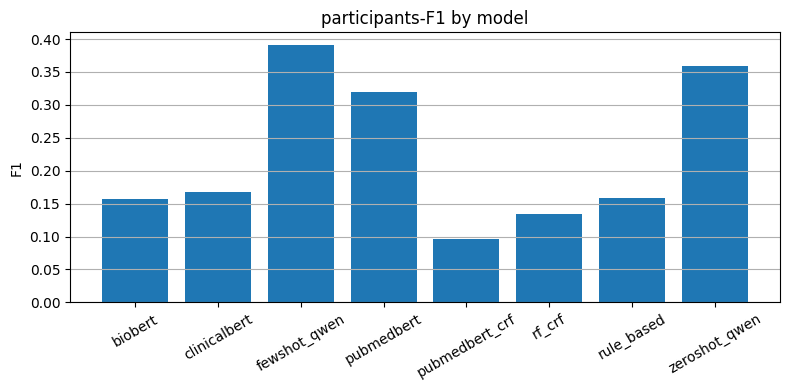

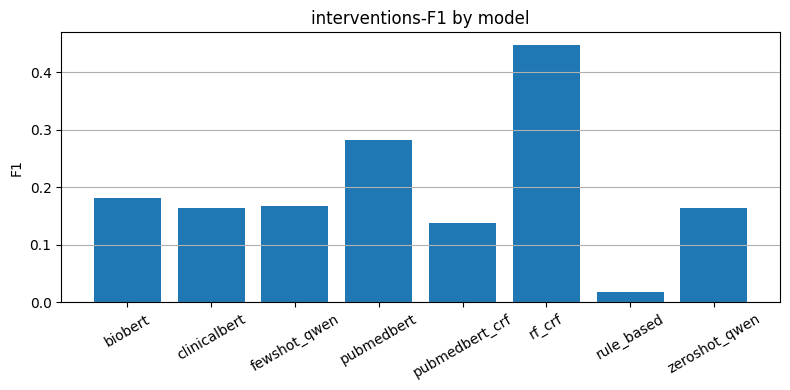

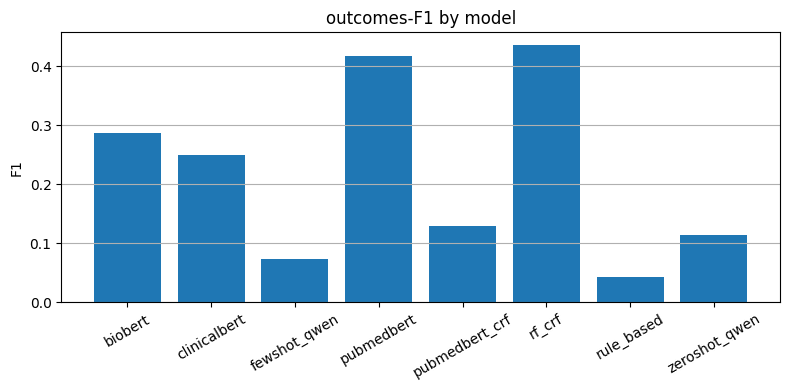

In [41]:
#plot
def plot_f1(score_tbl):
    field=["participants","interventions","outcomes"]
    for fld in field:
        s=score_tbl[score_tbl["field"]==fld].sort_values("variant")
        plt.figure(figsize=(8,4))
        plt.bar(s["variant"].astype(str),s["span_f1"])
        plt.xticks(rotation=30)
        plt.ylabel("F1")
        plt.title(f"{fld}-F1 by model")
        plt.grid(axis="y")
        plt.tight_layout()
        plt.show()
plot_f1(fld_score)


        


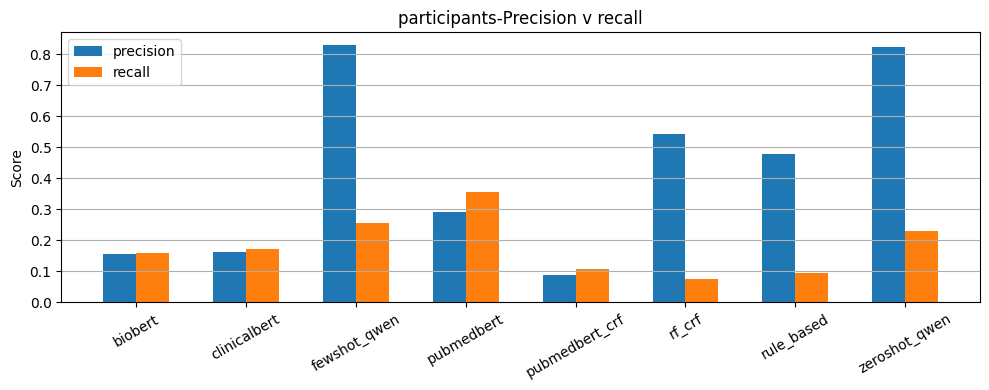

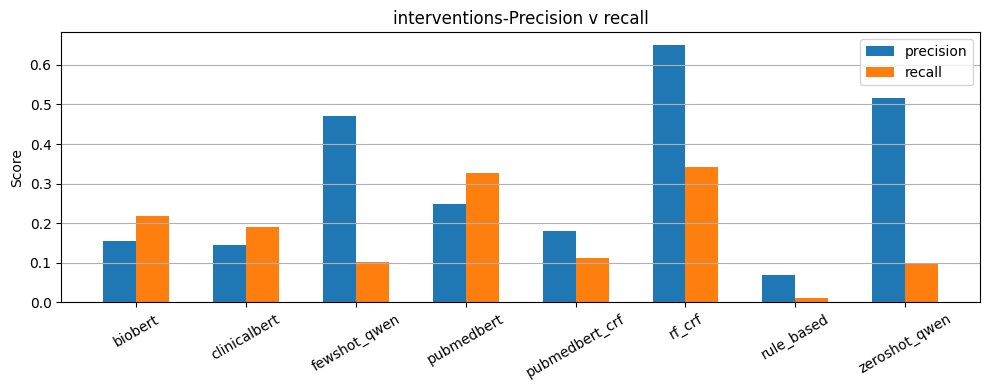

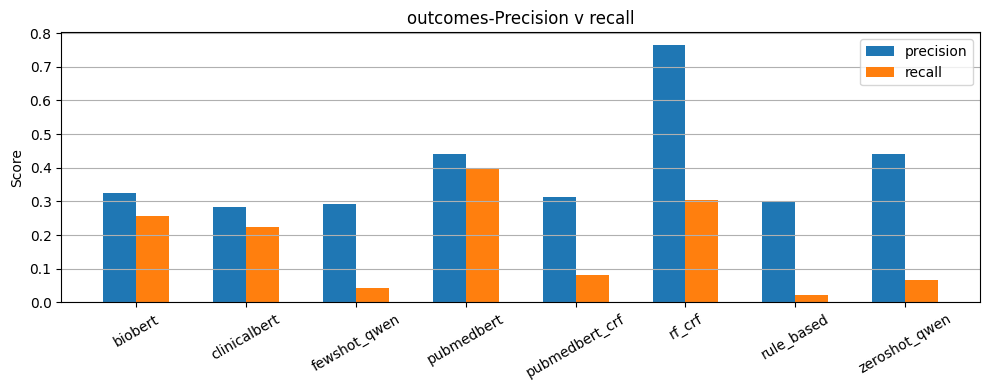

In [42]:
def plot_pvc(score_tbl):
    field=["participants","interventions","outcomes"]

    for fld in field:
        s=score_tbl[score_tbl["field"]==fld].sort_values("variant")
        x=np.arange(len(s))
        width=0.3
        plt.figure(figsize=(10,4))
        plt.bar(x-width/2,s["span_precision"],width,label="precision")
        plt.bar(x+width/2,s["span_recall"],width,label="recall")
        plt.xticks(x,s["variant"].astype(str),rotation=30)
        plt.ylabel("Score")
        plt.title(f"{fld}-Precision v recall")
        plt.legend()
        plt.grid(axis="y")
        plt.tight_layout()
        plt.show()
plot_pvc(fld_score)
    

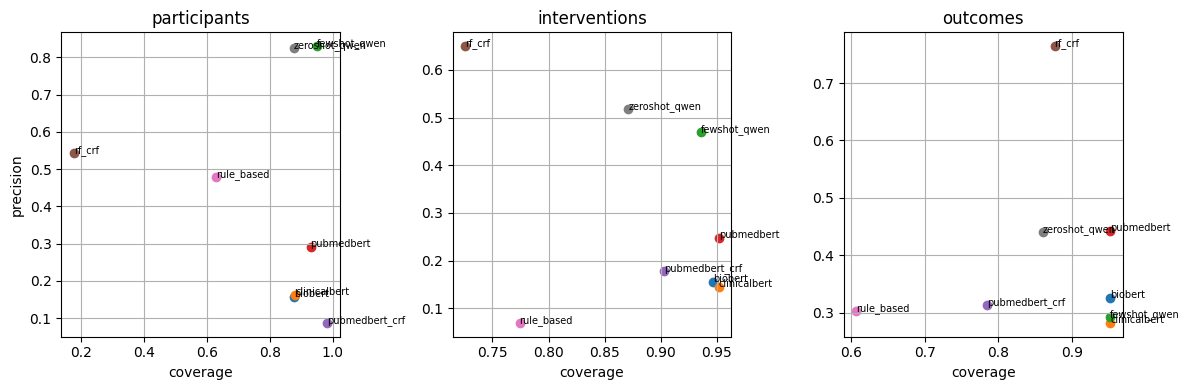

In [43]:
def plot_cvp(score_tbl):
    field=["participants","interventions","outcomes"]
    fig,axs=plt.subplots(1,3,figsize=(12,4))
    for i,fld in enumerate(field):
        s=score_tbl[score_tbl["field"]==fld].sort_values("variant")
        for _, row in s.iterrows():
            axs[i].scatter(row["coverage"],row["span_precision"])
            axs[i].text(
                row["coverage"],row["span_precision"],str(row["variant"]),fontsize=7)
        axs[i].set_title(fld)
        axs[i].set_xlabel("coverage")
        axs[i].grid(True)
    axs[0].set_ylabel("precision")
    plt.tight_layout()
    plt.show()
plot_cvp(fld_score)
            

In [44]:
queries=[
    {"name":"diabetes participants","must_have":{"participants":["diabetes"]}},
    {"name":"exercise interventions","must_have":{"interventions":["exercise"]}},
    {"name":"blood pressure outcomes","must_have":{"outcomes":["blood pressure"]}},
    {"name":"diabetes and metformin","must_have":{"participants":["diabetes"], "interventions":["metformin"]}},
    {"name":"exercise and blood pressure","must_have":{"interventions":["exercise"],"outcomes":["blood pressure"]}}]

all_qscore=eval_q_all(run_all,queries,top_k=10)
all_qscore=all_qscore.sort_values(["query","variant"]).reset_index(drop=True)

table_qall=all_qscore.pivot_table(index="query",columns="variant",values=["precision","recall","f1"])
display(table_qall.round(3))


f1                                       \
variant                     biobert clinicalbert fewshot_qwen pubmedbert   
query                                                                      
blood pressure outcomes       0.667        0.286        0.667       1.00   
diabetes and metformin        0.286        0.286        0.286       0.50   
diabetes participants         0.286        0.286        0.286       0.50   
exercise and blood pressure   0.778        0.429        0.700       0.90   
exercise interventions        0.889        0.571        0.889       0.75   
overall                       0.581        0.371        0.565       0.73   

                                                                            \
variant                     pubmedbert_crf rf_crf rule_based zeroshot_qwen   
query                                                                        
blood pressure outcomes              0.250  0.857      0.800         0.800   
diabetes and metformin               0.000  0.286      0.286         0.500   
diabetes participants                0.000  0.286      0.286         0.500   
exercise and blood pressure          0.400  0.700      0.600         0.824   
exercise interventions               0.571  0.750      0.333         0.857   
overall                              0.244  0.576      0.461         0.696   

                            precision               ...             \
variant                       biobert clinicalbert  ... rule_based   
query                                               ...              
blood pressure outcomes         1.000        1.000  ...      0.667   
diabetes and metformin          1.000        1.000  ...      1.000   
diabetes participants           1.000        1.000  ...      1.000   
exercise and blood pressure     0.875        0.750  ...      0.600   
exercise interventions          0.800        0.667  ...      0.500   
overall                         0.935        0.883  ...      0.753   

                                           recall                            \
variant                     zeroshot_qwen biobert clinicalbert fewshot_qwen   
query                                                                         
blood pressure outcomes               1.0   0.500        0.167        0.667   
diabetes and metformin                1.0   0.167        0.167        0.167   
diabetes participants                 1.0   0.167        0.167        0.167   
exercise and blood pressure           1.0   0.700        0.300        0.700   
exercise interventions                1.0   1.000        0.500        1.000   
overall                               1.0   0.507        0.260        0.540   

                                                                         \
variant                     pubmedbert pubmedbert_crf rf_crf rule_based   
query                                                                     
blood pressure outcomes          1.000          0.167  1.000      1.000   
diabetes and metformin           0.333          0.000  0.167      0.167   
diabetes participants            0.333          0.000  0.167      0.167   
exercise and blood pressure      0.900          0.300  0.700      0.600   
exercise interventions           0.750          0.500  0.750      0.250   
overall                          0.663          0.193  0.557      0.437   

                                           
variant                     zeroshot_qwen  
query                                      
blood pressure outcomes             0.667  
diabetes and metformin              0.333  
diabetes participants               0.333  
exercise and blood pressure         0.700  
exercise interventions              0.750  
overall                             0.557  

[6 rows x 24 columns]

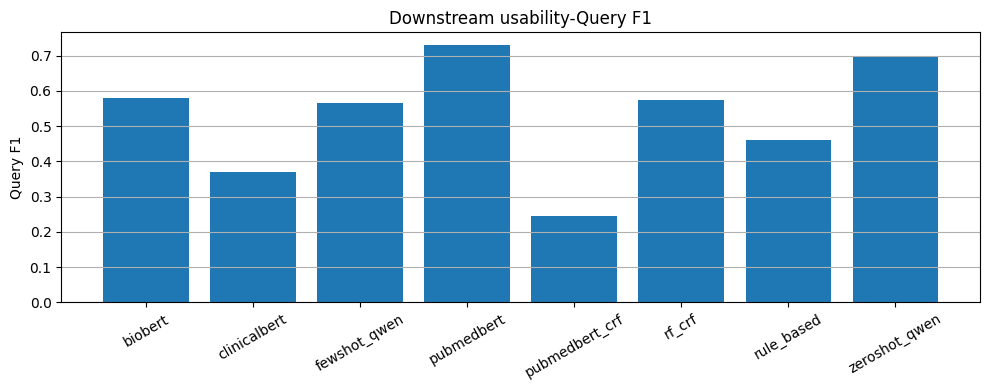

In [45]:
def plot_qf1(query_score):
    s=query_score[query_score["query"]=="overall"].copy()
    s=s.sort_values("variant")
    plt.figure(figsize=(10,4))
    plt.bar(s["variant"].astype(str),s["f1"])
    plt.xticks(rotation=30)
    plt.ylabel("Query F1")
    plt.title("Downstream usability-Query F1")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()
plot_qf1(all_qscore)

In [ ]:
# common errors for all models

def get_error_r(tbl,model_name, field,match_threshold=0.5):
    sub=tbl[tbl["variant"]==model_name].copy()
    w=[]

    for _, row in sub.iterrows():
        gold_spans=split_span(row[f"{field}_gold"])
        pred_spans=split_span(row[f"{field}_pred"])
        tp,fp,fn=match_span(gold_spans,pred_spans,match_threshold)
        if fp>0 or fn>0:
            long_span=False
            has_number=False
            for span in gold_spans:
                if len(span.split())>5:
                    long_span=True
                if re.search(r"\d", span):
                    has_number=True

            w.append({"variant":model_name,"field":field,"doc_id":row["doc_id"],"fp":fp,"fn":fn,"long_span_error":long_span,"number_error":has_number})
    return pd.DataFrame(w)


def err(tbl,match_threshold=0.5):
    all_rows=[]
    for model_name in tbl["variant"].unique():
        for field in pio_fields:
            error_rows=get_error_r(tbl,model_name,field,match_threshold)
            all_rows.append(error_rows)
    error_df=pd.concat(all_rows, ignore_index=True)

    smy=error_df.groupby(["variant","field"]).agg(error_docs=("doc_id","count"),avg_fp=("fp","mean"),avg_fn=("fn","mean"),
        long_span_errors=("long_span_error","sum"),number_errors=("number_error","sum")).reset_index()

    error_patterns=[]
    for _, row in smy.iterrows():
        if row["avg_fp"]>row["avg_fn"]:
            error_patterns.append("over predicting")
        else:
            error_patterns.append("under predicting")
    smy["main_error_pattern"]=error_patterns
    smy=smy[["variant","field","avg_fp","avg_fn","main_error_pattern","long_span_errors","number_errors","error_docs"]]
    return error_df,smy

error_df,error_summary=err(run_all,match_threshold=0.5)
display(error_summary.round(2))

,variant,field,avg_fp,avg_fn,main_error_pattern,long_span_errors,number_errors,error_docs
0,biobert,interventions,6.05,3.98,over predicting,45,17,184
1,biobert,outcomes,4.50,6.33,under predicting,159,54,186
2,biobert,participants,2.77,2.70,over predicting,149,140,184
3,clinicalbert,interventions,5.70,4.08,over predicting,45,17,186
4,clinicalbert,outcomes,4.85,6.60,under predicting,159,54,186
5,clinicalbert,participants,2.87,2.67,over predicting,149,138,183
6,fewshot_qwen,interventions,0.58,4.57,under predicting,45,17,184
7,fewshot_qwen,outcomes,0.86,8.16,under predicting,159,54,186
8,fewshot_qwen,participants,0.18,2.56,under predicting,141,133,172
9,pubmedbert,interventions,5.13,3.46,over predicting,45,17,182
